<a href="https://colab.research.google.com/github/josdank/Fundamentos-de-IA/blob/Pruebas/Examen_bim1_FIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

# Carga y Exploración de Datos
url = "https://raw.githubusercontent.com/josdank/Fundamentos-de-IA/Pruebas/dataClientesGimnasio.csv"
df = pd.read_csv(url)
print(df.head())
print(df.info())

# Eliminación de columnas irrelevantes
columnas_a_eliminar = ['ID', 'Sexo']  # Eliminamos columnas que no aportan al análisis
df_clean = df.drop(columns=columnas_a_eliminar)
print("Columnas después de limpieza:", df_clean.columns)


   ID  Edad Sexo  Altura  Peso  FrecuenciaSemanal  Antiguedad
0   1    24    M     175    72                  4          12
1   2    31    F     160    60                  3           6
2   3    27    M     180    80                  5          24
3   4    35    F     165    68                  2           3
4   5    22    M     178    75                  6          18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 60 non-null     int64 
 1   Edad               60 non-null     int64 
 2   Sexo               60 non-null     object
 3   Altura             60 non-null     int64 
 4   Peso               60 non-null     int64 
 5   FrecuenciaSemanal  60 non-null     int64 
 6   Antiguedad         60 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 3.4+ KB
None
Columnas después de limpieza: Index(['Edad', 'Al

In [32]:
# Preprocesamiento - Normalización
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

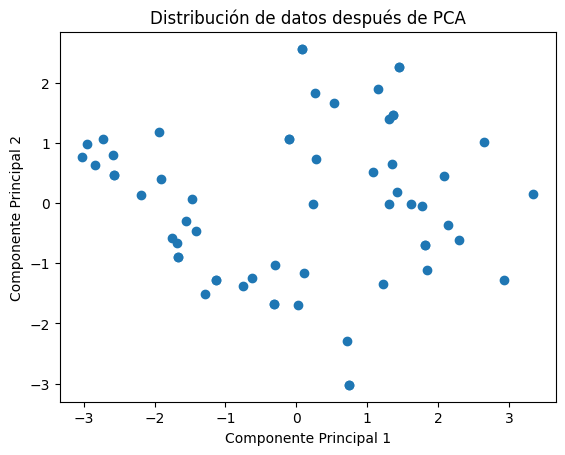

In [31]:
# Reducción de Dimensionalidad con PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.scatter(df_pca[:, 0], df_pca[:, 1])
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Distribución de datos después de PCA")
plt.show()

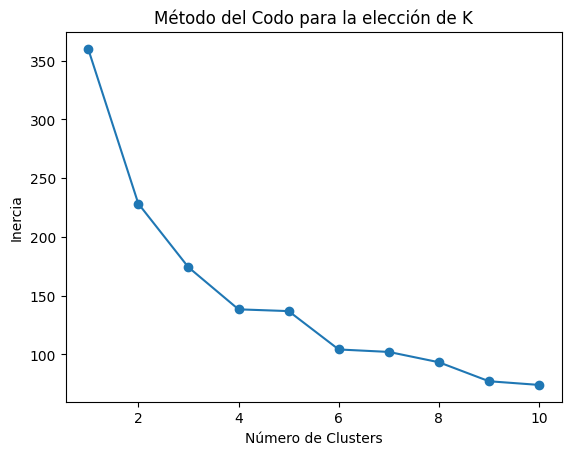

In [22]:
# Calcular el método del codo para K-Means
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo para la elección de K")
plt.show()

# **Respuesta:**
# El punto donde la curva empieza a doblarse indica el número óptimo de clusters. Se usa este número para K-Means.


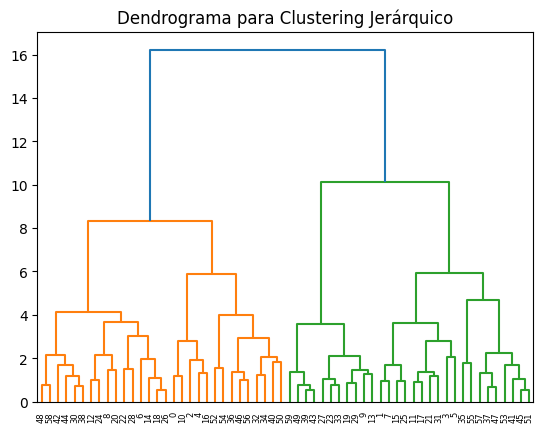

In [23]:
# K-Means con el número óptimo de clusters obtenido con el método del codo
optimal_k = 3  # Cambiar según el método del codo
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(df_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(df_scaled)

# Clustering Jerárquico
linkage_matrix = linkage(df_scaled, method='ward')
dendrogram(linkage_matrix)
plt.title("Dendrograma para Clustering Jerárquico")
plt.show()

# **Respuesta:**
# K-Means crea grupos equilibrados, DBSCAN detecta zonas densas, y el clustering jerárquico permite visualizar relaciones entre datos.


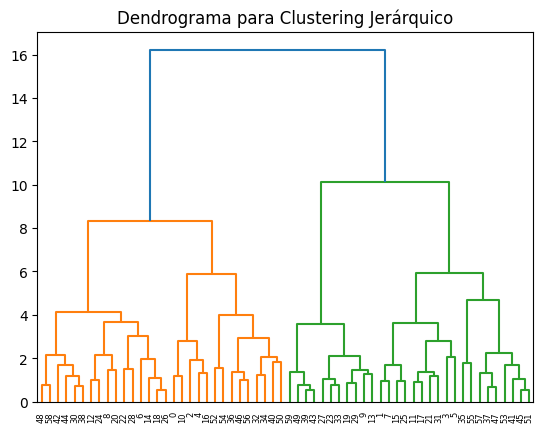

In [24]:
# K-Means con el número óptimo de clusters obtenido con el método del codo
optimal_k = 3  # Cambiar según el método del codo
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(df_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(df_scaled)

# Clustering Jerárquico
linkage_matrix = linkage(df_scaled, method='ward')
dendrogram(linkage_matrix)
plt.title("Dendrograma para Clustering Jerárquico")
plt.show()

# **Respuesta:**
# K-Means crea grupos equilibrados, DBSCAN detecta zonas densas, y el clustering jerárquico permite visualizar relaciones entre datos.


In [25]:
# Calcular Silhouette Score
silhouette_kmeans = silhouette_score(df_scaled, labels_kmeans)
silhouette_dbscan = silhouette_score(df_scaled, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1

print(f"Silhouette Score - K-Means: {silhouette_kmeans}")
print(f"Silhouette Score - DBSCAN: {silhouette_dbscan}")

# **Respuesta:**
# K-Means es simple y efectivo para datos bien distribuidos, DBSCAN es ideal para estructuras más complejas.


Silhouette Score - K-Means: 0.2970675261536332
Silhouette Score - DBSCAN: -1


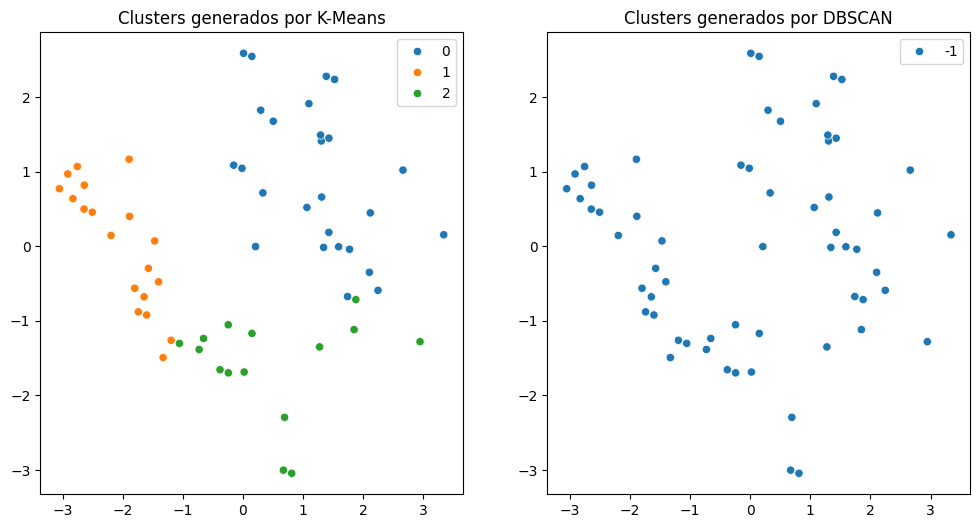

In [26]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=labels_kmeans, palette="tab10")
plt.title("Clusters generados por K-Means")

plt.subplot(1, 2, 2)
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=labels_dbscan, palette="tab10")
plt.title("Clusters generados por DBSCAN")

plt.show()

# **Respuesta:**
# Los clusters de K-Means están bien definidos, mientras que DBSCAN detecta zonas de mayor densidad sin imponer un número fijo de grupos.


In [27]:
# **Respuesta:**
# Los modelos de clustering permiten descubrir estructuras sin necesidad de etiquetas previas, brindando una comprensión profunda de los datos.
